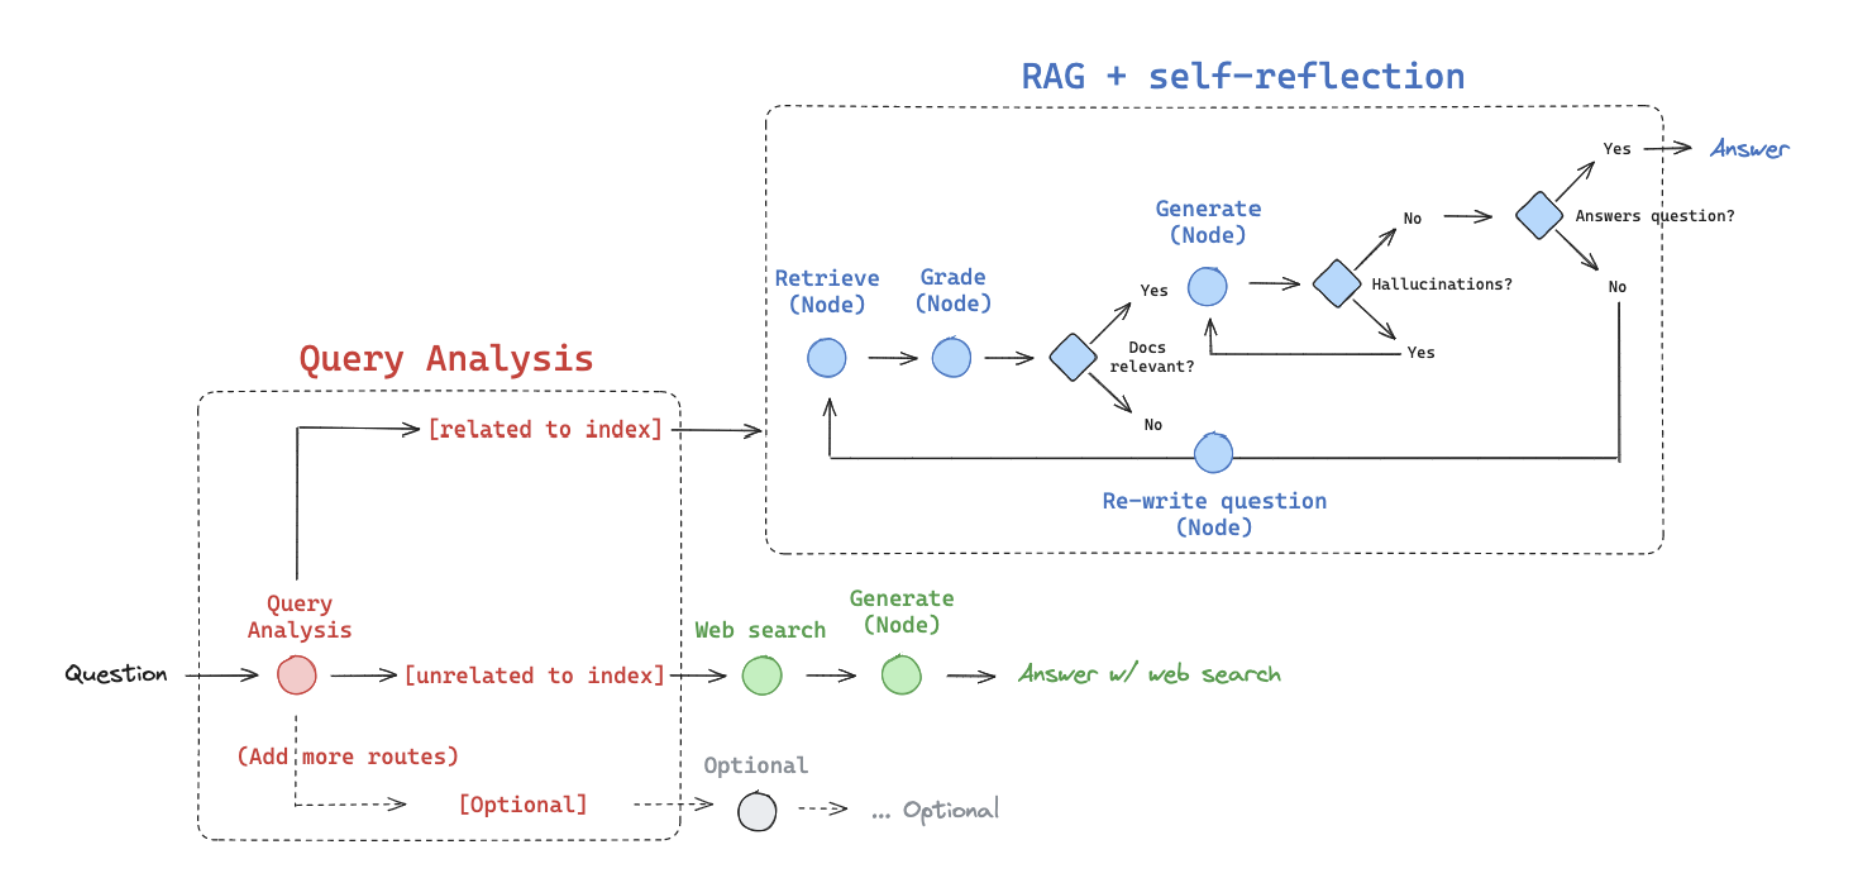
1. 쿼리 분석
    1. 질문이 들어오면 분석 → Query Analysis
    2. `[related to index]` → 쿼리가 벡터스토어에 가지고 있는 정보와 관련이 있다면, RAG 로직을 태운다 [파란색]
2. 파란색 → self-RAG 와 똑같다. 
    1. 이 self-RAG를 서브 그래프로 취급하여 연결하는 원리
3. 웹 서칭 → 질문 분석 했는데, 벡터스토어와 관련이 없으면 웹 검색 로직을 태운다 [CRAG]
4. 옵션 → 쿼리 분석을 했는데, 간단한 질문이라면? (대한민국의 수도는? 과 같은 질문) → 굳이 벡터 스토어나 웹 검색을 할 필요 없이 LLM 학습 데이터에 있는 걸로 간단하게 호출해서 답변 
    1. 여기서는 작은 mini모델을 써서 저렴하게 가도 됨.

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
"""
[개발해야 할 노드]

1. Query Analysis (질문 분석기)
2. Web Search 노드
3. Generate 노드
4. Optional 노드
"""

In [ ]:
from typing_extensions import List, TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List
    answer: str
    
graph_builder = StateGraph(AgentState)

In [ ]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=3,
    search_depth = "advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)

# 노드 생성
def web_search(state: AgentState):
    query=state['query']
    results = tavily_search_tool.invoke(query)
    print(f'web_search === {results}')
    return {'context':results} # result는 List 형태

In [ ]:
from langsmith import Client


client = Client()

In [ ]:
from langchain_ollama import ChatOllama
from langchain_core.output_parsers import StrOutputParser

generate_prompt = client.pull_prompt(
    "rlm/rag-prompt",
    dangerously_pull_public_prompt=True,
    )

generate_llm = ChatOllama(
    model='exaone3.5:7.8b', 
    num_predict=512,  # 생성할 최대 토큰 수
)

def web_generate(state:AgentState):
    context = state['context']  # 웹 기반으로 답변을 생성하는 경우, 좋은 LLM을 활용한다. (기본 답변은 gpt-mini 활용)
    query = state['query']

    rag_chain = generate_prompt | generate_llm | StrOutputParser()
    response = rag_chain.invoke({'question': query, 'context': context})  

    return {'answer': response} 

In [ ]:

# 통상적으로 gpt-mini를 활용함 (경량모델이나 저렴한 모델을 활용 -> 현 프로젝트에서는 로컬 LLM 활용)
basic_llm = ChatOllama(
    model='exaone3.5:7.8b',    
    num_predict=512,  # 생성할 최대 토큰 수
)


def basic_generate(state: AgentState):
    query = state['query']
    basic_llm_chain = basic_llm | StrOutputParser()   # 그냥 basic_llm.invoke(query) : BaseMessage 타입이 나오게 되므로 StrOutputParser 를 활용하여 string 형태로 변환해야 한다.
    llm_response = basic_llm_chain.invoke(query)

    return {'answer': llm_response}

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

"""
# 랭그래프의 개념에서 "라우터" 라는 개념이 있음 : 라우터가 질문 분석기의 역할을 하게 된다
"""

# system 프롬프트 : 사용자가 할 질문에 대해서 정보를 제공
router_system_prompt = """
You are an expert at routing a user's question to 'vector_store', 'llm', or 'web_search'.
'vector_store' contains information about income tax up to December 2024.
if you think the question is simple enough use 'llm'
if you think you need to search the web to answer the question use 'web_search'
"""

# 프롬프트 생성
router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}')
])

# router 는 질문 분석기 -> 간단하기 때문에, mini 모델(경량화) 활용해도 됨
router_llm = ChatOllama(
    model='exaone3.5:7.8b',
)

def router(state:AgentState):
    """
        질문 분석기 -> LLM을 기반으로 질문을 분석해서 어떤 그래프를 태울지 결정
        Router 의 역할과 동일하다. 
    """
    query = state['query']
    router_chain = router_prompt | router_llm | StrOutputParser()
    route = router_chain.invoke({'query': query})  # query 를 state에서 추출해서 router 체이닝
    print(f'route === {route}')  # 로그
    return route

In [ ]:
## node 추가
"""

"""
graph_builder.add_node('web_search', web_search)
graph_builder.add_node('web_generate', web_generate)
graph_builder.add_node('basic_generate', basic_generate)

SyntaxError: unterminated string literal (detected at line 2) (553845566.py, line 2)